# Simulación de agentes: mapa, fuego y POI

Ejecuta el notebook con **Ejecutar todo**. La vista del mapa aparece primero sin fuego para compararla con la imagen de referencia.

Las líneas azules son paredes, las verdes son puertas y las de azul cielo son entradas. Los bordes negros conservan la distribución de referencia; se quitaron los cuatro bordes marcados en rojo. Las paredes y puertas cerradas bloquean el fuego. El movimiento de bomberos y el daño estructural siguen pendientes.


## 1. Importaciones


In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

plt.rcParams["animation.html"] = "jshtml"
plt.rcParams["animation.embed_limit"] = 50  # MB para la animación dentro del notebook.

## 2. Mapa según la imagen

Los bordes se identifican con índices desde cero: `(fila, límite de columna)` para verticales y `(límite de fila, columna)` para horizontales. Las puertas empiezan cerradas.

Las entradas comunican una celda exterior con una interior. `puede_pasar_agente` permite consultar ese cruce; el fuego permanece dentro del tablero jugable.


In [2]:
FILAS_JUGABLES = 6
COLUMNAS_JUGABLES = 8
FILAS_MAPA = FILAS_JUGABLES + 2
COLUMNAS_MAPA = COLUMNAS_JUGABLES + 2

MARCO = 9
VACIO, HUMO, FUEGO, POI, BOMBERO = 0, 1, 2, 3, 4
ABIERTO, PARED, PUERTA_CERRADA, PUERTA_ABIERTA, ENTRADA = 0, 1, 2, 3, 4

mapa = np.full((FILAS_MAPA, COLUMNAS_MAPA), MARCO, dtype=int)
mapa[1:-1, 1:-1] = VACIO
tablero = mapa[1:-1, 1:-1]
paredes_verticales = np.zeros((FILAS_JUGABLES, COLUMNAS_JUGABLES + 1), dtype=int)
paredes_horizontales = np.zeros((FILAS_JUGABLES + 1, COLUMNAS_JUGABLES), dtype=int)


def validar_borde(matriz, fila, columna):
    if not (isinstance(fila, (int, np.integer)) and isinstance(columna, (int, np.integer))):
        raise ValueError("Los índices del borde deben ser enteros.")
    if not (0 <= fila < matriz.shape[0] and 0 <= columna < matriz.shape[1]):
        raise ValueError("El borde está fuera del mapa.")


def poner_pared_vertical(fila, limite_columna):
    validar_borde(paredes_verticales, fila, limite_columna)
    paredes_verticales[fila, limite_columna] = PARED


def poner_pared_horizontal(limite_fila, columna):
    validar_borde(paredes_horizontales, limite_fila, columna)
    paredes_horizontales[limite_fila, columna] = PARED


def poner_puerta_vertical(fila, limite_columna, abierta=False):
    validar_borde(paredes_verticales, fila, limite_columna)
    paredes_verticales[fila, limite_columna] = PUERTA_ABIERTA if abierta else PUERTA_CERRADA


def poner_puerta_horizontal(limite_fila, columna, abierta=False):
    validar_borde(paredes_horizontales, limite_fila, columna)
    paredes_horizontales[limite_fila, columna] = PUERTA_ABIERTA if abierta else PUERTA_CERRADA


def cambiar_puerta(matriz, fila, columna, abierta):
    validar_borde(matriz, fila, columna)
    if matriz[fila, columna] not in (PUERTA_CERRADA, PUERTA_ABIERTA):
        raise ValueError("No hay una puerta en ese borde.")
    matriz[fila, columna] = PUERTA_ABIERTA if abierta else PUERTA_CERRADA


def abrir_puerta_vertical(fila, limite_columna):
    cambiar_puerta(paredes_verticales, fila, limite_columna, True)


def cerrar_puerta_vertical(fila, limite_columna):
    cambiar_puerta(paredes_verticales, fila, limite_columna, False)


def abrir_puerta_horizontal(limite_fila, columna):
    cambiar_puerta(paredes_horizontales, limite_fila, columna, True)


def cerrar_puerta_horizontal(limite_fila, columna):
    cambiar_puerta(paredes_horizontales, limite_fila, columna, False)


# Base negra del mapa original.
paredes_verticales[:, 0] = PARED
paredes_verticales[:, -1] = PARED
paredes_horizontales[0, :] = PARED
paredes_horizontales[-1, :] = PARED
for fila in range(FILAS_JUGABLES):
    poner_pared_vertical(fila, 2)
    poner_pared_vertical(fila, 5)
for columna in range(COLUMNAS_JUGABLES):
    poner_pared_horizontal(2, columna)
    poner_pared_horizontal(4, columna)
for indice in ((1, 2), (4, 2), (2, 5), (5, 5)):
    paredes_verticales[indice] = ABIERTO
for indice in ((2, 1), (2, 6), (4, 3), (4, 7)):
    paredes_horizontales[indice] = ABIERTO

# Trazos rojos: quitar estos bordes.
BORDES_QUITADOS_VERTICALES = ((0, 2), (3, 5), (5, 2))
BORDES_QUITADOS_HORIZONTALES = ((2, 0),)
for indice in BORDES_QUITADOS_VERTICALES:
    paredes_verticales[indice] = ABIERTO
for indice in BORDES_QUITADOS_HORIZONTALES:
    paredes_horizontales[indice] = ABIERTO

# Trazos azules: paredes nuevas. La línea superior ocupa dos filas.
PAREDES_AZULES_VERTICALES = ((0, 3), (1, 3), (2, 6), (4, 7))
PAREDES_AZULES_HORIZONTALES = ((2, 4), (2, 6), (4, 7))
for indice in PAREDES_AZULES_VERTICALES:
    poner_pared_vertical(*indice)
for indice in PAREDES_AZULES_HORIZONTALES:
    poner_pared_horizontal(*indice)

# Trazos verdes: cinco puertas verticales y dos horizontales.
PUERTAS_VERTICALES = ((1, 5), (2, 2), (3, 6), (5, 5), (5, 7))
PUERTAS_HORIZONTALES = ((2, 7), (4, 3))
for indice in PUERTAS_VERTICALES:
    poner_puerta_vertical(*indice)
for indice in PUERTAS_HORIZONTALES:
    poner_puerta_horizontal(*indice)

# Azul cielo: accesos entre el exterior y el interior, desde cero.
ENTRADAS = {
    "arriba": {"exterior": (-1, 5), "interior": (0, 5), "borde": ("horizontal", 0, 5)},
    "izquierda": {"exterior": (2, -1), "interior": (2, 0), "borde": ("vertical", 2, 0)},
    "derecha": {"exterior": (3, 8), "interior": (3, 7), "borde": ("vertical", 3, 8)},
    "abajo": {"exterior": (6, 2), "interior": (5, 2), "borde": ("horizontal", 6, 2)},
}
for acceso in ENTRADAS.values():
    orientacion, fila, columna = acceso["borde"]
    bordes = paredes_verticales if orientacion == "vertical" else paredes_horizontales
    bordes[fila, columna] = ENTRADA


def es_celda_interior(fila, columna):
    return 0 <= fila < FILAS_JUGABLES and 0 <= columna < COLUMNAS_JUGABLES


def puede_pasar(r, c, nr, nc):
    """Propagación entre celdas interiores; nunca permite fuego en el marco."""
    if not (es_celda_interior(r, c) and es_celda_interior(nr, nc)):
        return False
    if abs(nr - r) + abs(nc - c) != 1:
        return False
    if r == nr:
        estado = paredes_verticales[r, max(c, nc)]
    else:
        estado = paredes_horizontales[max(r, nr), c]
    return estado in (ABIERTO, PUERTA_ABIERTA)


def puede_pasar_agente(r, c, nr, nc):
    """Consulta de movimiento interior o cruce de una de las cuatro entradas."""
    if es_celda_interior(r, c) and es_celda_interior(nr, nc):
        return puede_pasar(r, c, nr, nc)
    for acceso in ENTRADAS.values():
        exterior, interior = acceso["exterior"], acceso["interior"]
        if ((r, c), (nr, nc)) not in ((exterior, interior), (interior, exterior)):
            continue
        orientacion, fila, columna = acceso["borde"]
        bordes = paredes_verticales if orientacion == "vertical" else paredes_horizontales
        return bordes[fila, columna] in (ABIERTO, PUERTA_ABIERTA, ENTRADA)
    return False


print("Área jugable:", tablero.shape)
print("Puertas verdes:", len(PUERTAS_VERTICALES) + len(PUERTAS_HORIZONTALES))
print("Entradas:", ", ".join(ENTRADAS))


Área jugable: (6, 8)
Puertas verdes: 7
Entradas: arriba, izquierda, derecha, abajo


### Vista del mapa sin fuego

Verde continuo = puerta cerrada; verde discontinuo = puerta abierta. Para comprobar un cambio, abre o cierra una puerta y vuelve a llamar a `mostrar_mapa()`.

```python
abrir_puerta_vertical(1, 5)
cerrar_puerta_vertical(1, 5)
abrir_puerta_horizontal(4, 3)
cerrar_puerta_horizontal(4, 3)
```

Por ejemplo, la entrada superior conecta `(-1, 5)` con `(0, 5)`: `puede_pasar_agente(-1, 5, 0, 5)` devuelve `True`.


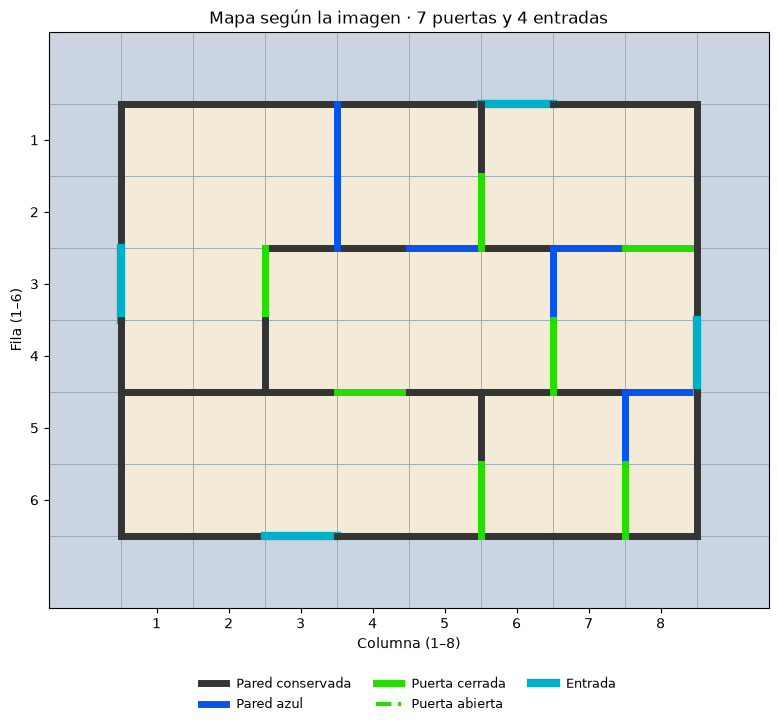

In [3]:
# Colores de la imagen de referencia.
COLOR_PARED_AZUL = "#0754ed"
COLOR_PUERTA = "#27dc00"
COLOR_ENTRADA = "#00afc8"
estilos_bordes = {
    PARED: {"color": "#343434", "linewidth": 5},
    PUERTA_CERRADA: {"color": COLOR_PUERTA, "linewidth": 5},
    PUERTA_ABIERTA: {"color": COLOR_PUERTA, "linewidth": 3, "linestyle": "--"},
    ENTRADA: {"color": COLOR_ENTRADA, "linewidth": 6},
}


def dibujar_bordes(eje, verticales, horizontales):
    for limite_fila, columna in np.ndindex(horizontales.shape):
        estado = horizontales[limite_fila, columna]
        estilo = estilos_bordes.get(estado)
        if estilo:
            estilo = estilo.copy()
            if estado == PARED and (limite_fila, columna) in PAREDES_AZULES_HORIZONTALES:
                estilo["color"] = COLOR_PARED_AZUL
            eje.plot([columna + 0.5, columna + 1.5], [limite_fila + 0.5] * 2, **estilo)
    for fila, limite_columna in np.ndindex(verticales.shape):
        estado = verticales[fila, limite_columna]
        estilo = estilos_bordes.get(estado)
        if estilo:
            estilo = estilo.copy()
            if estado == PARED and (fila, limite_columna) in PAREDES_AZULES_VERTICALES:
                estilo["color"] = COLOR_PARED_AZUL
            eje.plot([limite_columna + 0.5] * 2, [fila + 0.5, fila + 1.5], **estilo)


leyenda_bordes = [
    Line2D([0], [0], label="Pared conservada", **estilos_bordes[PARED]),
    Line2D([0], [0], color=COLOR_PARED_AZUL, linewidth=5, label="Pared azul"),
    Line2D([0], [0], label="Puerta cerrada", **estilos_bordes[PUERTA_CERRADA]),
    Line2D([0], [0], label="Puerta abierta", **estilos_bordes[PUERTA_ABIERTA]),
    Line2D([0], [0], label="Entrada", **estilos_bordes[ENTRADA]),
]


def mostrar_mapa():
    figura, eje = plt.subplots(figsize=(10, 8))
    figura.subplots_adjust(bottom=0.16)
    colores = ["#f3ead8"] * 9 + ["#cbd5e1"]
    eje.imshow(mapa, cmap=ListedColormap(colores), vmin=0, vmax=MARCO)
    dibujar_bordes(eje, paredes_verticales, paredes_horizontales)
    eje.set_xlim(-0.5, COLUMNAS_MAPA - 0.5)
    eje.set_ylim(FILAS_MAPA - 0.5, -0.5)
    eje.set_xticks(range(1, COLUMNAS_JUGABLES + 1))
    eje.set_yticks(range(1, FILAS_JUGABLES + 1))
    eje.set_xticks(np.arange(-0.5, COLUMNAS_MAPA, 1), minor=True)
    eje.set_yticks(np.arange(-0.5, FILAS_MAPA, 1), minor=True)
    eje.grid(False)
    eje.grid(which="minor", color="#94a3b8", linewidth=0.6)
    eje.tick_params(which="minor", bottom=False, left=False)
    eje.set_xlabel("Columna (1–8)")
    eje.set_ylabel("Fila (1–6)")
    eje.set_title("Mapa según la imagen · 7 puertas y 4 entradas")
    eje.legend(handles=leyenda_bordes, loc="upper center", bbox_to_anchor=(0.5, -0.10),
               ncol=3, frameon=False, fontsize=9)
    return figura, eje


figura_mapa, eje_mapa = mostrar_mapa()
plt.show()


## 3. Configuración de POI y fuego


In [4]:
#POIs
ROWS_POIS = FILAS_JUGABLES
COLS_POIS = COLUMNAS_JUGABLES

POIS_INICIALES = [(2, 4), (5, 1), (5, 8)]


def sacar_poi_de_bolsa(bolsa_pois):
    tipos_disponibles = (["victima"] * bolsa_pois["victima"]) + (["falsa_alarma"] * bolsa_pois["falsa_alarma"])
    if not tipos_disponibles:
        return None  # bolsa agotada
    tipo = random.choice(tipos_disponibles)
    bolsa_pois[tipo] -= 1
    return 2 if tipo == "victima" else 1


# Fuego

ROWS_FUEGO = FILAS_JUGABLES
COLS_FUEGO = COLUMNAS_JUGABLES

FUEGO_INICIAL = [
    (1, 7), (4, 3), (5, 2), (1, 5), (2, 2),
    (2, 6), (6, 1), (1, 8), (2, 1), (6, 4),
]


## 4. Propagación y reposición de POI

`explosion` y `flashover` consultan `puede_pasar` antes de cruzar a una celda vecina.


In [5]:
def revelar_y_perder_poi(r, c, matrixPois, matrixPoisRevelado):
    if matrixPois[r, c] == 0:
        return None
    tipo = "victima_perdida" if matrixPois[r, c] == 2 else "falsa_alarma_quemada"
    matrixPoisRevelado[r, c] = True  # el fuego revela el POI justo antes de destruirlo
    matrixPois[r, c] = 0
    return (tipo, r, c)

# Falta poner el daño a las paredes
# Falta hacer debilitamiento si cae un fuego en un bombero
# Falta: revelar un POI (matrixPoisRevelado[r, c] = True) cuando un bombero entra a esa celda,

def explosion(r, c, matrix, matrixPois, matrixPoisRevelado):
    direcciones = [(-1, 0), (1, 0), (0, -1), (0, 1)]
    eventos_pois = []
    for dr, dc in direcciones:
        actual_r, actual_c = r, c
        while True:
            nr, nc = actual_r + dr, actual_c + dc
            # Se comprueba cada borde, incluso entre celdas que ya tienen fuego.
            if not puede_pasar(actual_r, actual_c, nr, nc):
                break
            if matrix[nr, nc] == FUEGO:
                actual_r, actual_c = nr, nc
                continue
            matrix[nr, nc] = FUEGO
            evento = revelar_y_perder_poi(nr, nc, matrixPois, matrixPoisRevelado)
            if evento is not None:
                eventos_pois.append(evento)
            break
    return eventos_pois


def flashover(matrix, matrixPois, matrixPoisRevelado):

    direcciones = [(-1, 0), (1, 0), (0, -1), (0, 1)]
    eventos_pois = []
    cambio = True
    while cambio:
        cambio = False
        for i in range(ROWS_FUEGO):
            for j in range(COLS_FUEGO):
                if matrix[i, j] != 1:
                    continue
                for dr, dc in direcciones:
                    ni, nj = i + dr, j + dc
                    if (0 <= ni < ROWS_FUEGO and 0 <= nj < COLS_FUEGO
                            and matrix[ni, nj] == FUEGO and puede_pasar(i, j, ni, nj)):
                        matrix[i, j] = 2
                        cambio = True
                        evento = revelar_y_perder_poi(i, j, matrixPois, matrixPoisRevelado)
                        if evento is not None:
                            eventos_pois.append(evento)
                        break
    return eventos_pois

def advance_fire(matrix, matrixPois, matrixPoisRevelado):

    fila = random.randint(1, ROWS_FUEGO)
    columna = random.randint(1, COLS_FUEGO)
    r, c = fila - 1, columna - 1
    eventos_pois = []

    # Cae humo (no afecta POIs)
    if matrix[r, c] == 0:
        matrix[r, c] = 1

    # Se convierte en fuego
    elif matrix[r, c] == 1:
        matrix[r, c] = 2
        evento = revelar_y_perder_poi(r, c, matrixPois, matrixPoisRevelado)
        if evento is not None:
            eventos_pois.append(evento)

    # Explosion
    elif matrix[r, c] == 2:
        eventos_pois.extend(explosion(r, c, matrix, matrixPois, matrixPoisRevelado))

    return fila, columna, eventos_pois

N_POIS_OBJETIVO = 3


def replenish_poi(matrixFuego, matrixPois, matrixPoisRevelado, bolsa_pois):
    eventos = []
    while np.count_nonzero(matrixPois) < N_POIS_OBJETIVO:
        r = random.randint(0, ROWS_FUEGO - 1)
        c = random.randint(0, COLS_FUEGO - 1)
        if matrixPois[r, c] != 0:
            continue  # ya hay un POI ahi: reroll
        tipo_valor = sacar_poi_de_bolsa(bolsa_pois)
        if tipo_valor is None:
            return eventos  # bolsa agotada, no se puede reponer mas
        matrixFuego[r, c] = 0  # limpiar fuego/humo antes de colocar el POI
        matrixPois[r, c] = tipo_valor
        matrixPoisRevelado[r, c] = False
        eventos.append(("poi_repuesto", r, c))
    return eventos


## 5. Simulación

Puedes cambiar `N_TURNOS_FUEGO` y `SEMILLA` aquí. Para probar las puertas, usa las funciones de apertura o cierre antes de ejecutar esta celda; por ejemplo, `abrir_puerta_vertical(1, 5)` o `abrir_puerta_horizontal(4, 3)`.

Esta celda reinicia fuego y POI y usa las paredes y puertas como estén configuradas. **Ejecutar todo** también restablece el mapa y cierra las siete puertas.


In [6]:
SEMILLA = 42  # None para obtener una partida diferente cada vez.
N_TURNOS_FUEGO = 20
LIMITE_VICTIMAS_PERDIDAS = 4  # derrota con 4+ victimas perdidas

# Al repetir esta celda se reinician fuego, POI, bolsa, contadores e historial.
random.seed(SEMILLA)
bolsa_pois = {"victima": 10, "falsa_alarma": 5}

#0 = vacio, 1 = falsa alarma, 2 = victima
matrixPois = np.zeros((ROWS_POIS, COLS_POIS), dtype=int)
matrixPoisRevelado = np.zeros((ROWS_POIS, COLS_POIS), dtype=bool)

for (fila, columna) in POIS_INICIALES:
    r, c = fila - 1, columna - 1
    matrixPois[r, c] = sacar_poi_de_bolsa(bolsa_pois)
    # matrixPoisRevelado queda en False: se colocan boca abajo
# 0 = vacio, 1 = humo, 2 = fuego
matrixFuego = np.zeros((ROWS_FUEGO, COLS_FUEGO), dtype=int)


for fila, columna in FUEGO_INICIAL:
    matrixFuego[fila - 1, columna - 1] = 2


historyFuego = [matrixFuego.copy()]
historyPois = [matrixPois.copy()]
historyPoisRevelado = [matrixPoisRevelado.copy()]
historyTargetFuego = [None]
historyEventoFuego = [None]
historyEventosPois = [[]]
historyParedesVerticales = [paredes_verticales.copy()]
historyParedesHorizontales = [paredes_horizontales.copy()]
historyVictimasPerdidas = [0]

victimas_perdidas = 0
derrota = False

for turno in range(N_TURNOS_FUEGO):
    antes = matrixFuego.copy()
    fila, columna, eventos_ignicion = advance_fire(matrixFuego, matrixPois, matrixPoisRevelado)
    evento = "explosion" if antes[fila - 1, columna - 1] == 2 else None
    eventos_flashover = flashover(matrixFuego, matrixPois, matrixPoisRevelado)

    eventos_turno = eventos_ignicion + eventos_flashover
    victimas_perdidas += sum(1 for (tipo, *_r) in eventos_turno if tipo == "victima_perdida")

    # Una derrota termina el turno antes de reponer fichas.
    derrota = victimas_perdidas >= LIMITE_VICTIMAS_PERDIDAS
    if not derrota:
        eventos_turno += replenish_poi(matrixFuego, matrixPois, matrixPoisRevelado, bolsa_pois)

    historyFuego.append(matrixFuego.copy())
    historyPois.append(matrixPois.copy())
    historyPoisRevelado.append(matrixPoisRevelado.copy())
    historyTargetFuego.append((fila, columna))
    historyEventoFuego.append(evento)
    historyEventosPois.append(eventos_turno)
    historyParedesVerticales.append(paredes_verticales.copy())
    historyParedesHorizontales.append(paredes_horizontales.copy())
    historyVictimasPerdidas.append(victimas_perdidas)

    if derrota:
        print(f"DERROTA: se perdieron {victimas_perdidas} victimas en el turno {turno + 1}.")
        break

if not derrota:
    print(f"Victimas perdidas al final de la simulacion: {victimas_perdidas} (limite de derrota: {LIMITE_VICTIMAS_PERDIDAS})")


Victimas perdidas al final de la simulacion: 1 (limite de derrota: 4)


## 6. Animación

Las filas 1–6 y columnas 1–8 corresponden al área jugable. El círculo marca dónde cayó la tirada.


In [7]:
# El marco se usa para dibujar; fuego y POI siguen siendo matrices de 6 × 8.
colores_mapa = ["#f3ead8", "#9ca3af", "#ef4444"] + ["#f3ead8"] * 6 + ["#cbd5e1"]
fuego_cmap = ListedColormap(colores_mapa)
fig_fuego, (ax_fuego, ax_eventos) = plt.subplots(
    1, 2, figsize=(12, 7), gridspec_kw={"width_ratios": [3, 1]}
)
fig_fuego.subplots_adjust(left=0.05, right=0.97, bottom=0.20, wspace=0.18)
mapa_inicial = mapa.copy()
mapa_inicial[1:-1, 1:-1] = historyFuego[0]
patch_fuego = ax_fuego.imshow(mapa_inicial, cmap=fuego_cmap, vmin=0, vmax=MARCO)
ax_fuego.set_xlim(-0.5, COLUMNAS_MAPA - 0.5)
ax_fuego.set_ylim(FILAS_MAPA - 0.5, -0.5)
ax_fuego.set_xticks(range(1, COLUMNAS_JUGABLES + 1))
ax_fuego.set_yticks(range(1, FILAS_JUGABLES + 1))
ax_fuego.set_xticks(np.arange(-0.5, COLUMNAS_MAPA, 1), minor=True)
ax_fuego.set_yticks(np.arange(-0.5, FILAS_MAPA, 1), minor=True)
ax_fuego.grid(False)
ax_fuego.grid(which="minor", color="#94a3b8", linewidth=0.6)
ax_fuego.tick_params(which="minor", bottom=False, left=False)
ax_fuego.set_xlabel("Columna (1–8)")
ax_fuego.set_ylabel("Fila (1–6)")
title_fuego = ax_fuego.set_title("Estado inicial")
ax_eventos.axis("off")
texto_eventos = ax_eventos.text(0, 1, "", transform=ax_eventos.transAxes, va="top", fontsize=10)
marca_tirada = ax_fuego.scatter([], [], s=650, facecolors="none", edgecolors="black", linewidths=2)

leyenda = [Patch(facecolor=colores_mapa[i], label=nombre)
           for i, nombre in enumerate(("Vacío", "Humo", "Fuego"))] + leyenda_bordes
ax_fuego.legend(handles=leyenda, loc="upper center", bbox_to_anchor=(0.5, -0.10),
                ncol=3, frameon=False, fontsize=9)



def dibujar_paredes(frame_idx):
    for linea in list(ax_fuego.lines):
        linea.remove()
    dibujar_bordes(ax_fuego, historyParedesVerticales[frame_idx], historyParedesHorizontales[frame_idx])


def dibujar_pois(frame_idx):
    for txt in list(ax_fuego.texts):
        txt.remove()
    matriz_pois = historyPois[frame_idx]
    matriz_revelado = historyPoisRevelado[frame_idx]
    for i, j in np.argwhere(matriz_pois != 0):
        if not matriz_revelado[i, j]:
            simbolo, color = "?", "#1e3a8a"
        elif matriz_pois[i, j] == 2:
            simbolo, color = "V", "blue"
        else:
            simbolo, color = "F", "green"
        # +1 por el marco exterior; la lógica sigue usando índices desde cero.
        ax_fuego.text(j + 1, i + 1, simbolo, ha="center", va="center", color=color,
                      fontsize=13, fontweight="bold",
                      bbox={"boxstyle": "circle,pad=0.2", "fc": "white", "ec": "none"})


def animate_fuego(i):
    mapa_frame = mapa.copy()
    mapa_frame[1:-1, 1:-1] = historyFuego[i]
    patch_fuego.set_data(mapa_frame)
    dibujar_paredes(i)
    dibujar_pois(i)
    target = historyTargetFuego[i]
    perdidas = historyVictimasPerdidas[i]
    titulo = "Estado inicial" if i == 0 else f"Turno {i}"
    if perdidas >= LIMITE_VICTIMAS_PERDIDAS:
        titulo += " · DERROTA"
    elif i == len(historyFuego) - 1:
        titulo += " · Fin de simulación"
    title_fuego.set_text(f"{titulo}\nVíctimas perdidas: {perdidas}/{LIMITE_VICTIMAS_PERDIDAS}")

    lineas = ["EVENTOS DEL TURNO", ""]
    if target is None:
        marca_tirada.set_offsets(np.empty((0, 2)))
    else:
        fila, columna = target  # La tirada ya se devuelve con filas/columnas desde uno.
        marca_tirada.set_offsets([[columna, fila]])
        lineas += [f"Tirada: fila {fila}, columna {columna}", ""]
    if historyEventoFuego[i] == "explosion":
        lineas += ["EXPLOSIÓN", ""]
    nombres_eventos = {"victima_perdida": "Víctima perdida",
                       "falsa_alarma_quemada": "Falsa alarma quemada", "poi_repuesto": "POI repuesto"}
    for tipo, r, c in historyEventosPois[i]:
        lineas += [nombres_eventos[tipo], f"Fila {r + 1}, columna {c + 1}", ""]
    if not historyEventosPois[i]:
        lineas += ["Sin cambios en los POI.", ""]
    lineas += ["? = POI sin revelar", "V = víctima revelada", "F = falsa alarma revelada"]
    texto_eventos.set_text("\n".join(lineas))
    return patch_fuego, title_fuego, texto_eventos, marca_tirada


animate_fuego(0)
anim_fuego = animation.FuncAnimation(
    fig_fuego, animate_fuego, frames=len(historyFuego), interval=600, blit=False, repeat=False
)
plt.close(fig_fuego)
anim_fuego
